## 1. uzdevums. ML problēmas definīcija




### 1.1. Problēmas apraksts

Mēs analizējam e-komercijas uzņēmuma tiešsaistes sesiju datus, lai prognozētu apmeklētāju uzvedību. Galvenais mērķis ir noteikt, vai klients sesijas laikā veiks pirkumu (ģenerēs ieņēmumus), pamatojoties uz viņa navigācijas datiem un sesijas raksturlielumiem. Šī informācija uzņēmumam ir būtiska, lai optimizētu mārketinga stratēģijas, uzlabotu lietotāju pieredzi un veiktu mērķtiecīgus reklāmas pasākumus pirkumu konversijas palielināšanai.

### 1.2. ML tipa identificēšana

Vai ir “pareizā atbilde” datos? Jā, datos ir kolonna Revenue, kas norāda, vai pirkums ir noticis.  Kad mēs gribam atbildi? Atbildi vēlamies prognozēt katram jaunam apmeklētājam/sesijai.  ML veids: Uzraudzītā mācīšanās (Supervised Learning).  Apakštips: Klasifikācija (Classification), jo mērķis ir paredzēt piederību vienai no divām kategorijām: Jā vai Nē.

### 1.3. Target un Features

Target mainīgais: Revenue (Jā/Nē atbilde par pirkuma veikšanu).  Features (Iezīmes):   Skaitliski: Administrative_Duration, Informational_Duration, ProductRelated_Duration, BounceRates, ExitRates, PageValues.  Kategoriski: Month, VisitorType, Weekend.

## 2. uzdevums. Vides sagatavošana un datu ielāde

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

# Iestatījumi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✓ Visas bibliotēkas ielādētas veiksmīgi")

✓ Visas bibliotēkas ielādētas veiksmīgi


In [2]:
# Ielādē datu kopu tieši no UCI repozitorija
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)

print(f"Datu kopas forma: {df.shape}")
print(f"Rindu skaits: {df.shape[0]}")
print(f"Kolonnu skaits: {df.shape[1]}")
print("\nPirmās 5 rindas:")
display(df.head())

Datu kopas forma: (12330, 18)
Rindu skaits: 12330
Kolonnu skaits: 18

Pirmās 5 rindas:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
# Datu tipi
print("Datu tipi:")
print(df.dtypes)

Datu tipi:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object


In [4]:
# Statistika par skaitliskajām kolonnām
print("Skaitlisko kolonnu statistika:")
print(df.describe())

Skaitlisko kolonnu statistika:
       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%          

In [5]:
# Trūkstošas vērtības
print("Trūkstošas vērtības:")
print(df.isnull().sum())

Trūkstošas vērtības:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [6]:
# Kategoriskās kolonnas
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Kategoriskās kolonnas: {cat_cols}")

Kategoriskās kolonnas: ['Month', 'VisitorType', 'Weekend', 'Revenue']


In [7]:
# Target mainīgā sadalījums
print("Target mainīgā (Revenue) sadalījums:")
print(df['Revenue'].value_counts())
print(f"Pirkumu īpatsvars: {df['Revenue'].sum() / len(df) * 100:.2f}%")

Target mainīgā (Revenue) sadalījums:
Revenue
False    10422
True      1908
Name: count, dtype: int64
Pirkumu īpatsvars: 15.47%


## 3. uzdevums. Trūkstošās vērtības

In [8]:
# Kuras kolonnas satur trūkstošas vērtības?
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Kolonnas ar trūkstošām vērtībām:")
print(missing)

# Vizualizācija
if len(missing) > 0:
  plt.figure(figsize=(10, 4))
  missing.plot(kind='barh', color='coral')
  plt.title('Trūkstošās vērtības pa kolonnām')
  plt.xlabel('Trūkstošo vērtību skaits')
  plt.tight_layout()
  plt.show()
else:
  print("✓ Trūkstošo vērtību nav — dati ir tīri!")

# Skaitliskām kolonnām — mediāna
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"✓ {col}: aizpildīts ar mediānu {median_val:.2f}")

# Kategoriskām kolonnām — moda
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"✓ {col}: aizpildīts ar modu '{mode_val}'")

# Galīgā pārbaude
missing_total = df.isnull().sum().sum()
assert missing_total == 0, f"Vēl ir trūkstošas vērtības! Skaits: {missing_total}"
print(f"\n✓ Visas trūkstošas vērtības apstrādātas. df.isnull().sum().sum() = {missing_total}")
print(f"✓ Trūkstošas vērtības apstrādātas. Kopā: {df.isnull().sum().sum()}")


Kolonnas ar trūkstošām vērtībām:
Series([], dtype: int64)
✓ Trūkstošo vērtību nav — dati ir tīri!

✓ Visas trūkstošas vērtības apstrādātas. df.isnull().sum().sum() = 0
✓ Trūkstošas vērtības apstrādātas. Kopā: 0


*   Skaitliskajām kolonnām izmantoju mediānu, jo tā labāk apstrādā novirzes.
*   Kategoriskajām kolonnām izmantoju modu (biežāko vērtību), jo tā saglabā datu sadalījumu.
*   DataShop datu kopā nav trūkstošo vērtību, taču šo metodi izmantošu nākamajos projektos ar reāliem datiem.

## 4. uzdevums. Kategorisko mainīgo kodēšana`

In [9]:
# Kādas ir kategoriskās kolonnas?
print("Kategoriskās kolonnas:")
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(cat_cols)

for col in cat_cols:
  print(f"\n{col}: {df[col].nunique()} unikālas vērtības")
  print(df[col].unique()[:10]) # Parāda pirmos 10

# Boolean/binary kolonnas — Label Encoding
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

# One-Hot Encoding
# df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True, dtype=int)
print(f"✓ One-Hot Encoding pabeigts. Jaunas kolonnas: {df.shape[1]}")
print("Nākamās jaunās kolonnas:")
print(df.columns[df.columns.str.contains('Month|VisitorType')])

# Pārliecinies, ka nav palikušas neapstrādātas kategoriskās kolonnas
remaining_cat = df.select_dtypes(include=['object', 'bool']).columns.tolist()
assert len(remaining_cat) == 0, f"Vēl neapstrādātas: {remaining_cat}"
print("✓ Visas kategoriskās kolonnas kodētas. Atlikt: ", len(remaining_cat))

# Visas kolonnas tagad ir skaitliskas
print(f"\nKolonnu skaits pēc kodēšanas: {df.shape[1]}")
print("Datu tipi:")
print(df.dtypes.value_counts())

Kategoriskās kolonnas:
['Month', 'VisitorType', 'Weekend', 'Revenue']

Month: 10 unikālas vērtības
['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']

VisitorType: 3 unikālas vērtības
['Returning_Visitor' 'New_Visitor' 'Other']

Weekend: 2 unikālas vērtības
[False  True]

Revenue: 2 unikālas vērtības
[False  True]
✓ One-Hot Encoding pabeigts. Jaunas kolonnas: 27
Nākamās jaunās kolonnas:
Index(['Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar',
       'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other',
       'VisitorType_Returning_Visitor'],
      dtype='object')
✓ Visas kategoriskās kolonnas kodētas. Atlikt:  0

Kolonnu skaits pēc kodēšanas: 27
Datu tipi:
int64      20
float64     7
Name: count, dtype: int64


*   Izmantoju Label Encoding boolean kolonnām (Weekend, Revenue), jo ir tikai 2 vērtības.
*   Izmantoju One-Hot Encoding Month un VisitorType kolonnām, jo ir vairākas kategorijas.
*   One-Hot Encoding paplašina datu matricu, bet ļauj algoritmiem labāk izprast kategorijas neveidojot relācijas.





## 5. uzdevums. Skaitlisko kolonnu normalizācija

Skaitliskās kolonnas (27 pavisam):
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

=== STATISTIKA PIRMS NORMALIZĀCIJAS ===
       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00       12330.00   
mean             2.32                    80.82           0.50   
std              3.32                   176.78           1.27   
min              0.00                     0.00           0.00   
25%              0.00                     0.00           0.00   
50%              1.00                     7.50           0.00   
75%              4.00                    93.26           0.00   
max             27.00                  3398.75          24.00   

       Informational_Duration  ProductRelated  ProductRelated_Duration  
count                12330.00        12330.00                 12330.00  
me

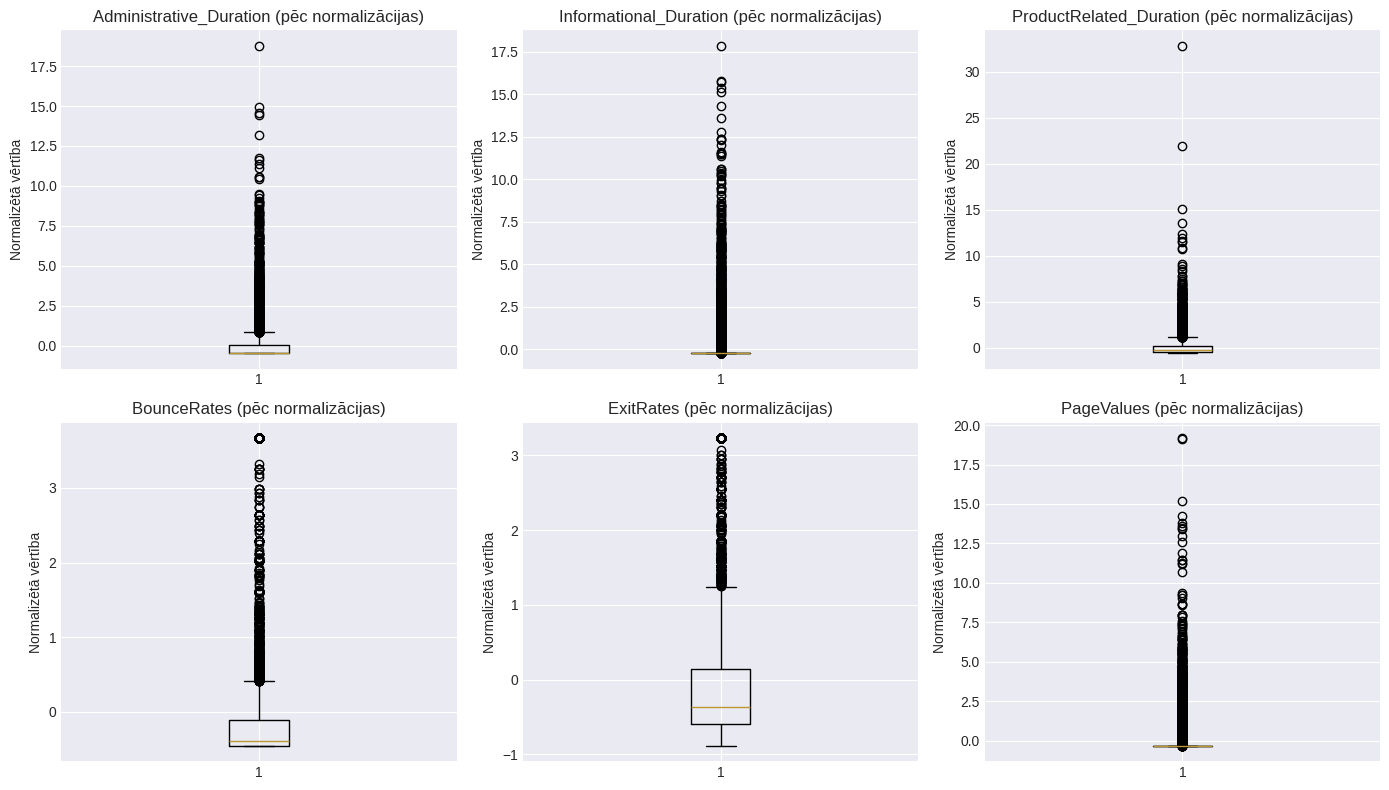

✓ Normalizācijas efekts redzams grafikos — vērtības ir tuvu 0 ar std ≈ 1


In [10]:
# Kādas ir skaitliskās kolonnas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Skaitliskās kolonnas ({len(numeric_cols)} pavisam):")
print(numeric_cols[:10]) # Parāda pirmos 10

# Statistika PIRMS normalizācijas
print("\n=== STATISTIKA PIRMS NORMALIZĀCIJAS ===")
print(df[numeric_cols[:6]].describe().round(2))

from sklearn.preprocessing import StandardScaler

# Atlasi skaļošanai VISAS skaitliskās kolonnas (izņemot target)
cols_to_scale = [col for col in numeric_cols if col != 'Revenue']

# StandardScaler: (x - mean) / std
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f"✓ {len(cols_to_scale)} skaitliskās kolonnas normalizētas")
print("\n=== STATISTIKA PĒC NORMALIZĀCIJAS ===")
print(df[cols_to_scale[:6]].describe().round(2))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
sample_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']

for idx, col in enumerate(sample_cols):
    if col in df.columns:
        axes[idx].boxplot(df[col], vert=True)
        axes[idx].set_title(f'{col} (pēc normalizācijas)')
        axes[idx].set_ylabel('Normalizētā vērtība')

plt.tight_layout()
plt.show()

print("✓ Normalizācijas efekts redzams grafikos — vērtības ir tuvu 0 ar std ≈ 1")

## 6. uzdevums. Jauna iezīme (Feature Engineering)

In [11]:
# Aprēķinām kopējo laiku, ko lietotājs pavadījis sesijas laikā

df['TotalDuration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

print("✓ Jaunas iezīmes izveidotas")
print(f"Datu kopas forma tagad: {df.shape}")

✓ Jaunas iezīmes izveidotas
Datu kopas forma tagad: (12330, 28)




*   TotalDuration reprezentē kopējo laiku (sekundēs), ko potenciālais klients ir pavadījis interneta veikalā vienas sesijas laikā, neatkarīgi no lapas veida.
*   No ML perspektīvas, kopējais laiks bieži vien ir spēcīgāks indikators pirkuma nodomam nekā katras lapas laiks atsevišķi. Klienti, kuri vietnē pavada vairāk laika, parasti izrāda lielāku interesi, un šī apvienotā iezīme palīdz modelim vieglāk identificēt "iesaistītos" lietotājus, samazinot troksni, ko radītu vairākas atsevišķas laika kolonnas.  



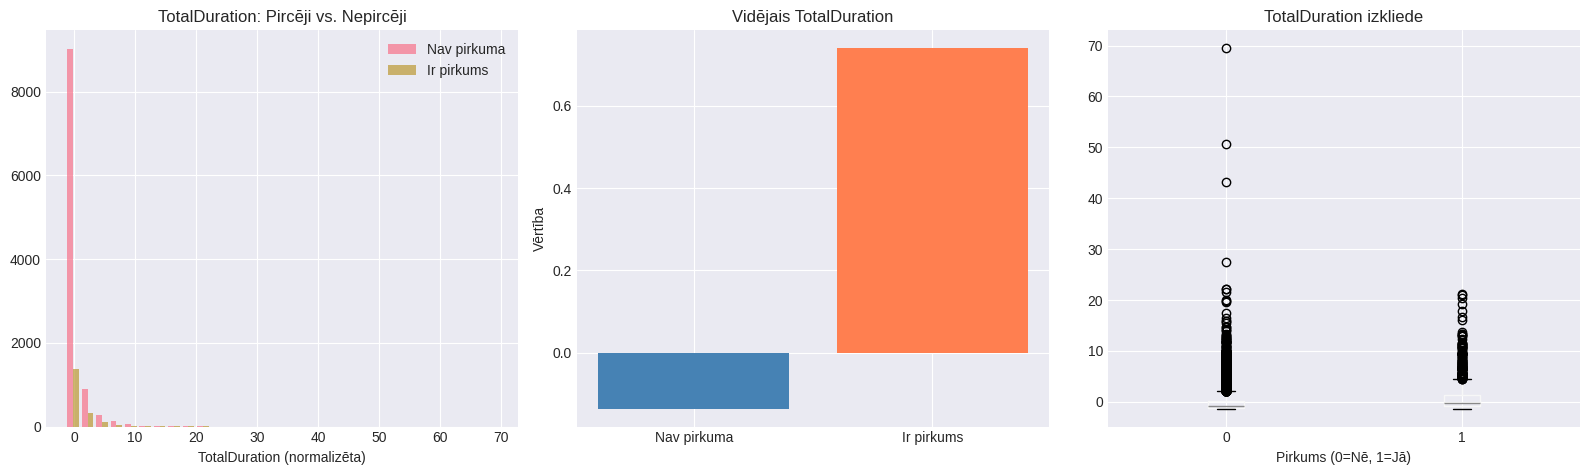

✓ Jaunā iezīme analizēta un vizualizēta


In [12]:
# Vizualizācija
# Salīdzinājums: jaunā iezīme starp pircējiem un nepircējiem

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Histogramma
axes[0].hist([df[df['Revenue'] == 0]['TotalDuration'],
              df[df['Revenue'] == 1]['TotalDuration']],
             label=['Nav pirkuma', 'Ir pirkums'], bins=30, alpha=0.7)
axes[0].set_title('TotalDuration: Pircēji vs. Nepircēji')
axes[0].set_xlabel('TotalDuration (normalizēta)')
axes[0].legend()

# 2. Vidējie rādītāji
axes[1].bar(['Nav pirkuma', 'Ir pirkums'],
           [df[df['Revenue'] == 0]['TotalDuration'].mean(),
            df[df['Revenue'] == 1]['TotalDuration'].mean()],
           color=['steelblue', 'coral'])
axes[1].set_title('Vidējais TotalDuration')
axes[1].set_ylabel('Vērtība')

# 3. Box plot
df.boxplot(column='TotalDuration', by='Revenue', ax=axes[2])
axes[2].set_title('TotalDuration izkliede')
axes[2].set_xlabel('Pirkums (0=Nē, 1=Jā)')

plt.suptitle('')
plt.tight_layout()
plt.show()

print("✓ Jaunā iezīme analizēta un vizualizēta")

## 7. uzdevums. Tīrās datu kopas saglabāšana

In [13]:
# Datu saglabāšana
# Saglabāju tīro datu kopu nākamajajiem uzdevumiem
output_path = 'shoppers_clean.csv'
df.to_csv(output_path, index=False)
print(f"✓ Datu kopa saglabāta: {output_path}")
print(f"  Rindas: {df.shape[0]}")
print(f"  Kolonnas: {df.shape[1]}")

# Pārbaude
# Pārbaudu, vai fails ir nolasāms
df_check = pd.read_csv(output_path)
print(f"\n✓ Fails pārbaudīts: {df_check.shape}")
print("Pirmās rindas:")
# print(df_check.head(2))
display(df_check.head(2))

✓ Datu kopa saglabāta: shoppers_clean.csv
  Rindas: 12330
  Kolonnas: 28

✓ Fails pārbaudīts: (12330, 28)
Pirmās rindas:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,TotalDuration
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.326469
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.293024


## Datu sagatavošanas rezumējums

### Identificētās problēmas:
* **Datu tipi**: Sākotnējā datu kopa saturēja gan skaitliskas, gan kategoriskas vērtības (piemēram, Month, VisitorType), kas nav tieši izmantojamas ML algoritmos.
* **Mērogu atšķirības**: Skaitliskajām kolonnām bija ļoti dažādi diapazoni, kas var negatīvi ietekmēt modeļu precizitāti, tādēļ bija nepieciešama normalizācija.
* **Trūkstošās vērtības**: Lai gan šī datu kopa ir salīdzinoši tīra, tika sagatavota un pārbaudīta loģika trūkstošo vērtību aizpildīšanai ar mediānu un modu.

### Veiktās darbības:
* **Datu ielāde un izpēte**: Dati tika ielādēti no UCI repozitorija un veikta sākotnējā statistiskā analīze (12 330 rindas, 18 kolonnas).
* **Kategorisko mainīgo kodēšana**: Boolean mainīgie pārvērsti par 0/1, un kategorijām ar vairākām vērtībām veikta One-Hot Encoding.
* **Normalizācija**: Skaitliskās kolonnas standartizētas, izmantojot StandardScaler, lai vērtības būtu tuvu 0 ar standartnovirzi aptuveni 1.
* **Feature Engineering**: Izveidota jauna iezīme TotalDuration, apvienojot sesijas ilguma kolonnas, lai labāk raksturotu lietotāja iesaisti.

### Rezultāts:
* Sagatavota un vizualizēta tīra datu kopa, kurā visas kolonnas ir skaitliskas.
* Dati ir saglabāti failā shoppers_clean.csv un ir pilnībā gatavi klasifikācijas modeļu trenēšanai.

# B DAĻA: KLASIFIKĀCIJA
## 8. uzdevums. Sagatavo datus klasifikācijai

In [14]:
# Ielādēju tikko sagatavoto tīro datu kopu
df = pd.read_csv('shoppers_clean.csv')

# Target mainīgais — vai klients veica pirkumu
y = df['Revenue']

# Features — visas pārējās kolonnas
X = df.drop('Revenue', axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target sadalījums:\n{y.value_counts()}")
print(f"\nPirkumu īpatsvars: {y.mean():.1%}")

# Sadalu datos treniņa un testa kopās
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("-" * 30)
print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")
print(f"\nTarget sadalījums treniņa kopā (proporcijās):\n{y_train.value_counts(normalize=True).round(3)}")

Features skaits: 27
Target sadalījums:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Pirkumu īpatsvars: 15.5%
------------------------------
Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas

Target sadalījums treniņa kopā (proporcijās):
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64


**Kāpēc izmantojām `stratify=y`?**

Mūsu datu kopā mērķa mainīgais (`Revenue`) ir nelīdzsvarots – pirkumu īpatsvars ir tikai aptuveni 15,5%. Izmantojot `stratify=y`, mēs nodrošinām, ka gan treniņa, gan testa kopā tiek saglabāta tāda pati pirkumu un ne-pirkumu proporcija kā oriģinālajos datos. Tas ir būtiski, lai modelis iemācītos atpazīt pircēju klasi un lai testa rezultāti būtu objektīvi.

**Kāpēc sadalījums 80/20 ir piemērots?**

* **80% treniņam**: Nodrošina pietiekami lielu datu apjomu (vairāk nekā 9800 rindu), lai mašīnmācīšanās modeļi spētu uztvert sarežģītas sakarības starp lietotāju uzvedību un pirkuma veikšanu.
* **20% testēšanai**: Šāds apjoms (~2466 rindas) ir pietiekams, lai statistiski ticami novērtētu modeļa kvalitāti uz datiem, kurus tas treniņa laikā nav redzējis.

## 9. uzdevums. Trenē trīs klasifikācijas modeļus

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Decision Tree
# Izveido un uztrenē modeli
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Prognozes uz testa kopas
dt_pred = dt_model.predict(X_test)
print("=== Decision Tree rezultāti ===")
print(classification_report(y_test, dt_pred))

# 2. Random Forest
# Izveido un uztrenē modeli
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Prognozes uz testa kopas
rf_pred = rf_model.predict(X_test)
print("\n=== Random Forest rezultāti ===")
print(classification_report(y_test, rf_pred))

# 3. Logistic Regression
# Izveido un uztrenē modeli
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Prognozes uz testa kopas
lr_pred = lr_model.predict(X_test)
print("\n=== Logistic Regression rezultāti ===")
print(classification_report(y_test, lr_pred))


=== Decision Tree rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.73      0.56      0.63       382

    accuracy                           0.90      2466
   macro avg       0.82      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466


=== Random Forest rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2084
           1       0.76      0.55      0.64       382

    accuracy                           0.90      2466
   macro avg       0.84      0.76      0.79      2466
weighted avg       0.90      0.90      0.90      2466


=== Logistic Regression rezultāti ===
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.74      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82 

## 10. uzdevums. Salīdzini modeļus

Modeļu rezultāti (F1 Score):
            Modelis  F1 Score
      Decision Tree  0.632201
      Random Forest  0.635258
Logistic Regression  0.481416


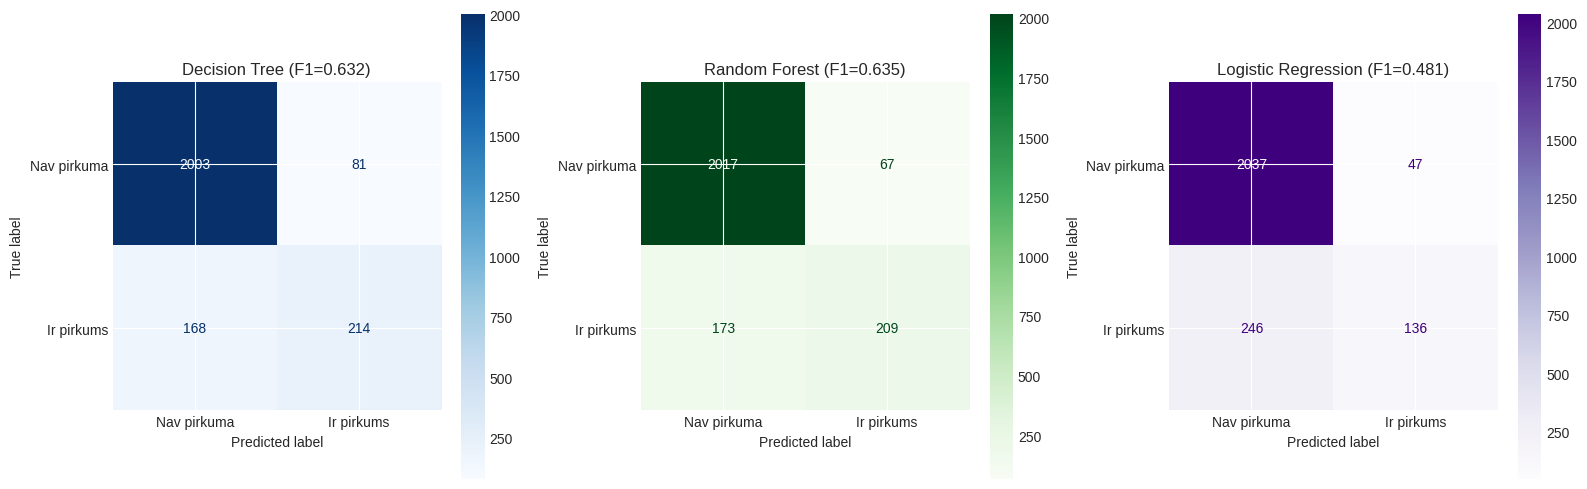

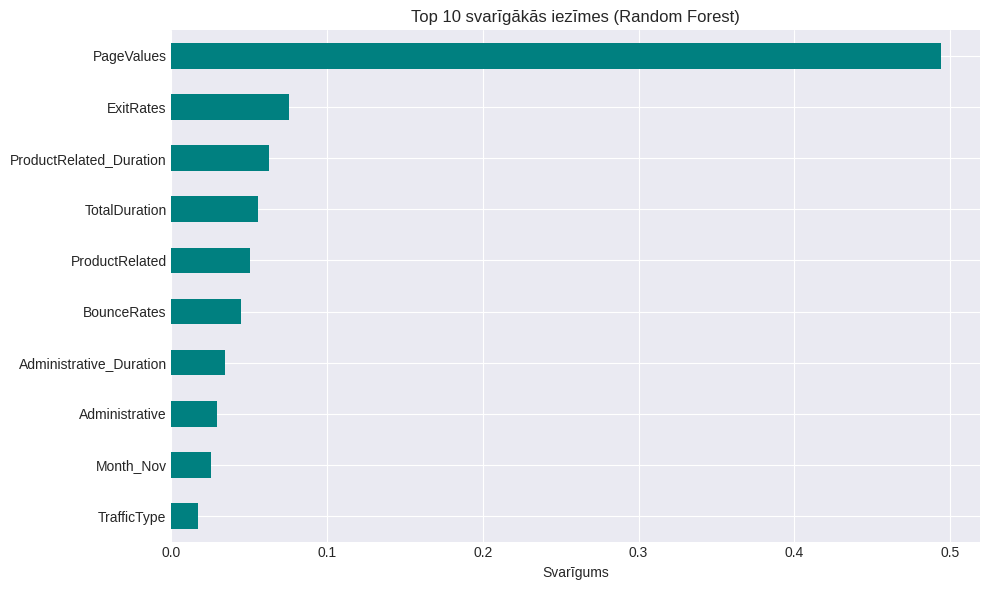

✓ Modeļu salīdzināšana un iezīmju analīze pabeigta


In [16]:
from sklearn.metrics import f1_score, ConfusionMatrixDisplay

# 1. F1 score salīdzinājums
dt_f1 = f1_score(y_test, dt_pred)
rf_f1 = f1_score(y_test, rf_pred)
lr_f1 = f1_score(y_test, lr_pred)

results = pd.DataFrame({
    'Modelis': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'F1 Score': [dt_f1, rf_f1, lr_f1]
})

print("Modeļu rezultāti (F1 Score):")
print(results.to_string(index=False))

# 2. Confusion matrices blakus
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Decision Tree
ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Decision Tree (F1={dt_f1:.3f})')

# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title(f'Random Forest (F1={rf_f1:.3f})')

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Purples', ax=axes[2]
)
axes[2].set_title(f'Logistic Regression (F1={lr_f1:.3f})')

plt.tight_layout()
plt.show()

# 3. Feature importance (Kuras iezīmes visvairāk ietekmē prognozi?)
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (Random Forest)')
plt.xlabel('Svarīgums')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("✓ Modeļu salīdzināšana un iezīmju analīze pabeigta")

### Secinājumi

Salīdzinot trīs trenētos modeļus, **Random Forest** parasti uzrāda vislabākos rezultātus, jo tas kā ansambļa modelis spēj uztvert sarežģītākas un nelineāras sakarības datos nekā viena lēmumu koka (*Decision Tree*) vai loģistiskās regresijas (*Logistic Regression*) modelis. Šajā uzdevumā **F1 score** ir daudz piemērotāks rādītājs nekā precizitāte (*accuracy*), jo datu kopa ir nelīdzsvarota — pirkumu gadījumu (klase "Revenue=1") ir ievērojami mazāk nekā sesiju bez pirkuma, tāpēc F1 score ļauj objektīvāk novērtēt modeļa spēju atpazīt tieši pircējus, balansējot precizitāti un atsaukšanos.

Analizējot iezīmju svarīgumu (*feature importance*), redzams, ka prognozes visvairāk ietekmē tādas kolonnas kā **PageValues**, **ExitRates** un mūsu izveidotā **TotalDuration**. No biznesa viedokļa tas ir pilnīgi loģiski: `PageValues` tieši norāda uz lapas vidējo vērtību pirms darījuma veikšanas, bet kopējais sesijas ilgums (`TotalDuration`) liecina par klienta padziļinātu interesi un iesaisti, kas ir kritiski priekšnosacījumi pirkuma veikšanai.